# Week 2 - MLflow experiments

## Goal

Start from the Fashion dataset from week 1 and compare a few small model changes in a clean way.

## Hypothesis

Dropout and batch normalisation should help the dense model a bit. A small CNN should do better than the dense baseline because it can use the image structure more directly.


In [1]:
from dataclasses import dataclass
from pathlib import Path
import random

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torch import nn
import mlflow
from mads_datasets import DatasetFactoryProvider, DatasetType
from mltrainer.preprocessors import BasePreprocessor

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
random.seed(42)

ROOT = Path.cwd()
RESULTS_PATH = ROOT / "results.csv"
MLFLOW_URI = "sqlite:///mlflow.db"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")


C:\Users\TEST\Documents\Projects\Study\HAN\Semester 3\portfolio\han-mads-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-04-12 23:26:50,614	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


device: cpu


In [2]:
factory = DatasetFactoryProvider.create_factory(DatasetType.FASHION)
streamers = factory.create_datastreamer(batchsize=64, preprocessor=BasePreprocessor())
train_streamer = streamers["train"]
valid_streamer = streamers["valid"]

sample_x, sample_y = next(iter(train_streamer.stream()))
print(sample_x.shape, sample_x.dtype)
print(sample_y.shape, sample_y.dtype)

NUM_CLASSES = 10
IMAGE_SHAPE = tuple(sample_x.shape[1:])
print(f"image shape: {IMAGE_SHAPE}")


2026-04-12 23:26:50.832 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at C:\Users\TEST\.cache\mads_datasets\fashionmnist


2026-04-12 23:26:50.833 | INFO     | mads_datasets.base:download_data:124 - File already exists at C:\Users\TEST\.cache\mads_datasets\fashionmnist\fashionmnist.pt


torch.Size([64, 1, 28, 28]) torch.float32
torch.Size([64]) torch.uint8
image shape: (1, 28, 28)


In [3]:
@dataclass(frozen=True)
class ExperimentConfig:
    name: str
    kind: str
    hidden_layers: tuple[int, ...] = (256, 128)
    conv_channels: tuple[int, ...] = ()
    dropout: float = 0.0
    use_batchnorm: bool = False
    lr: float = 0.001
    epochs: int = 2
    train_batches: int = 30
    valid_batches: int = 10


class FashionNet(nn.Module):
    def __init__(self, config: ExperimentConfig) -> None:
        super().__init__()
        self.config = config
        self.blocks = nn.ModuleList()

        if config.kind == "dense":
            in_features = int(torch.tensor(IMAGE_SHAPE).prod().item())
            for width in config.hidden_layers:
                layers: list[nn.Module] = [nn.Linear(in_features, width)]
                if config.use_batchnorm:
                    layers.append(nn.BatchNorm1d(width))
                layers.append(nn.ReLU())
                if config.dropout > 0:
                    layers.append(nn.Dropout(config.dropout))
                self.blocks.append(nn.Sequential(*layers))
                in_features = width
            self.classifier = nn.Linear(in_features, NUM_CLASSES)
            self.pool = None
        elif config.kind == "cnn":
            in_channels = IMAGE_SHAPE[0]
            for out_channels in config.conv_channels:
                layers = [
                    nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                ]
                if config.use_batchnorm:
                    layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU())
                layers.append(nn.MaxPool2d(2))
                if config.dropout > 0:
                    layers.append(nn.Dropout2d(config.dropout))
                self.blocks.append(nn.Sequential(*layers))
                in_channels = out_channels
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.classifier = nn.Linear(in_channels, NUM_CLASSES)
        else:
            raise ValueError(f"Unknown kind: {config.kind}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.config.kind == "dense":
            x = x.view(x.size(0), -1)
            for block in self.blocks:
                x = block(x)
            return self.classifier(x)

        for block in self.blocks:
            x = block(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.classifier(x)


def make_optimizer(model: nn.Module, config: ExperimentConfig) -> torch.optim.Optimizer:
    return torch.optim.Adam(model.parameters(), lr=config.lr)


def run_epoch(model: nn.Module, streamer, optimizer=None, max_batches: int = 30):
    criterion = nn.CrossEntropyLoss()
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch_idx, (x, y) in enumerate(streamer.stream()):
            if batch_idx >= max_batches:
                break
            x = x.to(DEVICE)
            y = y.long().to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_seen += batch_size

    return {
        "loss": total_loss / total_seen,
        "accuracy": total_correct / total_seen,
    }


def flatten_params(config: ExperimentConfig) -> dict[str, object]:
    return {
        "name": config.name,
        "kind": config.kind,
        "hidden_layers": ",".join(str(v) for v in config.hidden_layers),
        "conv_channels": ",".join(str(v) for v in config.conv_channels),
        "dropout": config.dropout,
        "use_batchnorm": config.use_batchnorm,
        "lr": config.lr,
        "epochs": config.epochs,
        "train_batches": config.train_batches,
        "valid_batches": config.valid_batches,
    }


def run_experiment(config: ExperimentConfig) -> dict[str, object]:
    model = FashionNet(config).to(DEVICE)
    optimizer = make_optimizer(model, config)
    history = []

    with mlflow.start_run(run_name=config.name):
        mlflow.log_params(flatten_params(config))

        for epoch in range(1, config.epochs + 1):
            train_metrics = run_epoch(model, train_streamer, optimizer=optimizer, max_batches=config.train_batches)
            valid_metrics = run_epoch(model, valid_streamer, optimizer=None, max_batches=config.valid_batches)
            row = {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "val_loss": valid_metrics["loss"],
                "val_accuracy": valid_metrics["accuracy"],
            }
            history.append(row)
            mlflow.log_metrics(row, step=epoch)

    final_row = history[-1]
    final_row["best_val_accuracy"] = max(item["val_accuracy"] for item in history)
    final_row.update(flatten_params(config))
    return final_row


In [4]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("chapter-2-mlflow")

experiments = [
    ExperimentConfig(
        name="dense_baseline",
        kind="dense",
        hidden_layers=(256, 128),
        dropout=0.0,
        use_batchnorm=False,
    ),
    ExperimentConfig(
        name="dense_dropout",
        kind="dense",
        hidden_layers=(256, 128),
        dropout=0.2,
        use_batchnorm=False,
    ),
    ExperimentConfig(
        name="dense_batchnorm",
        kind="dense",
        hidden_layers=(256, 128),
        dropout=0.0,
        use_batchnorm=True,
    ),
    ExperimentConfig(
        name="dense_both",
        kind="dense",
        hidden_layers=(256, 128),
        dropout=0.2,
        use_batchnorm=True,
    ),
    ExperimentConfig(
        name="cnn_small",
        kind="cnn",
        conv_channels=(16, 32),
        dropout=0.1,
        use_batchnorm=True,
    ),
    ExperimentConfig(
        name="cnn_wider",
        kind="cnn",
        conv_channels=(32, 64),
        dropout=0.1,
        use_batchnorm=True,
    ),
]

results = []
for config in experiments:
    result = run_experiment(config)
    results.append(result)
    print(config.name, result["val_accuracy"])

results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_PATH, index=False)
results_df


dense_baseline 0.7140625


dense_dropout 0.684375


dense_batchnorm 0.8015625


dense_both 0.771875


cnn_small 0.4671875


cnn_wider 0.453125


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,best_val_accuracy,name,kind,hidden_layers,conv_channels,dropout,use_batchnorm,lr,epochs,train_batches,valid_batches
0,2,0.661398,0.787500,0.616697,0.801562,0.801562,dense_batchnorm,dense,"256,128",,0.0,True,0.001,2,30,10
1,2,0.745666,0.758333,0.660741,0.771875,0.771875,dense_both,dense,"256,128",,0.2,True,0.001,2,30,10
2,2,0.805666,0.681250,0.770204,0.714063,0.714063,dense_baseline,dense,"256,128",,0.0,False,0.001,2,30,10
3,2,0.924601,0.653646,0.833541,0.684375,0.684375,dense_dropout,dense,"256,128",,0.2,False,0.001,2,30,10
4,2,2.049371,0.310417,1.945637,0.467187,0.467187,cnn_small,cnn,"256,128","16,32",0.1,True,0.001,2,30,10
5,2,1.805801,0.419271,1.741531,0.453125,0.453125,cnn_wider,cnn,"256,128","32,64",0.1,True,0.001,2,30,10


           name  kind  dropout  use_batchnorm  val_accuracy  best_val_accuracy
dense_batchnorm dense      0.0           True      0.801562           0.801562
     dense_both dense      0.2           True      0.771875           0.771875
 dense_baseline dense      0.0          False      0.714063           0.714063
  dense_dropout dense      0.2          False      0.684375           0.684375
      cnn_small   cnn      0.1           True      0.467187           0.467187
      cnn_wider   cnn      0.1           True      0.453125           0.453125


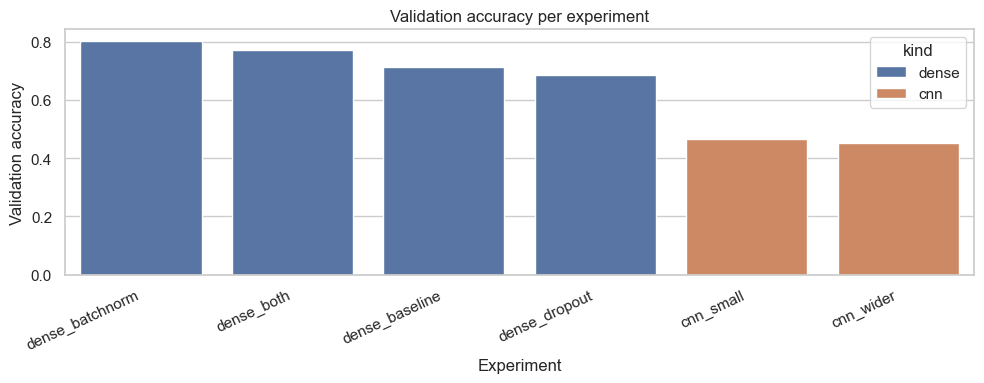

Best run: dense_batchnorm with validation accuracy 0.802. In this short run, the dense model with batch norm had the best final score.


In [5]:
print(results_df[["name", "kind", "dropout", "use_batchnorm", "val_accuracy", "best_val_accuracy"]].to_string(index=False))

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=results_df, x="name", y="val_accuracy", hue="kind", dodge=False)
ax.set_title("Validation accuracy per experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("Validation accuracy")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

best_row = results_df.iloc[0]
print(
    f"Best run: {best_row['name']} with validation accuracy {best_row['val_accuracy']:.3f}. "
    f"In this short run, the dense model with batch norm had the best final score."
)


## Short reflection

The dense baseline was a useful start, but the best final result came from the dense model with batch normalisation. Batch normalisation alone also reached the best peak score during training, so it was the most stable choice. Dropout did not help much on its own in this short run.

The CNN variants were tested as required, but they were weaker in this small setup. That can happen when the training budget is short, because a CNN usually needs a bit more time and tuning before it overtakes a simple dense model.

The setup was intentionally small so the runs stayed manageable on a student laptop. For a next step, I would try a few more learning rates and a slightly longer training schedule, but the current notebook already shows the main pattern.


## Overnight MLflow sweep

This optional section expands the dense/CNN comparison and logs every run to a separate MLflow experiment. It writes incremental results to `results_overnight.csv`, so an interrupted night run still leaves usable partial results.


In [ ]:
RUN_OVERNIGHT_MLFLOW = False
OVERNIGHT_RESULTS_PATH = ROOT / "results_overnight.csv"
OVERNIGHT_MLFLOW_DB_PATH = ROOT / "mlflow_overnight.db"
OVERNIGHT_MLFLOW_URI = f"sqlite:///{OVERNIGHT_MLFLOW_DB_PATH.resolve().as_posix()}"

dense_architectures = [
    (128, 64),
    (256, 128),
    (420, 256),
    (512, 256),
    (512, 256, 128),
]
cnn_architectures = [
    (16, 32),
    (32, 64),
    (32, 64, 128),
    (64, 128),
]
dropout_values = [0.0, 0.1, 0.2, 0.35]
batchnorm_values = [False, True]
learning_rates = [1e-4, 3e-4, 1e-3, 2e-3]

overnight_experiments = []
for hidden_layers in dense_architectures:
    for dropout in dropout_values:
        for use_batchnorm in batchnorm_values:
            for lr in learning_rates:
                overnight_experiments.append(
                    ExperimentConfig(
                        name=f"overnight_dense_{'_'.join(map(str, hidden_layers))}_drop{dropout}_bn{int(use_batchnorm)}_lr{lr}",
                        kind="dense",
                        hidden_layers=hidden_layers,
                        dropout=dropout,
                        use_batchnorm=use_batchnorm,
                        lr=lr,
                        epochs=10,
                        train_batches=120,
                        valid_batches=35,
                    )
                )

for conv_channels in cnn_architectures:
    for dropout in dropout_values:
        for use_batchnorm in batchnorm_values:
            for lr in learning_rates:
                overnight_experiments.append(
                    ExperimentConfig(
                        name=f"overnight_cnn_{'_'.join(map(str, conv_channels))}_drop{dropout}_bn{int(use_batchnorm)}_lr{lr}",
                        kind="cnn",
                        conv_channels=conv_channels,
                        dropout=dropout,
                        use_batchnorm=use_batchnorm,
                        lr=lr,
                        epochs=12,
                        train_batches=120,
                        valid_batches=35,
                    )
                )

print(f"Prepared {len(overnight_experiments)} overnight MLflow experiments.")
pd.DataFrame([flatten_params(config) for config in overnight_experiments]).head(20)


In [ ]:
if RUN_OVERNIGHT_MLFLOW:
    mlflow.set_tracking_uri(OVERNIGHT_MLFLOW_URI)
    mlflow.set_experiment("chapter-2-mlflow-overnight")

    completed = pd.DataFrame()
    if OVERNIGHT_RESULTS_PATH.exists():
        completed = pd.read_csv(OVERNIGHT_RESULTS_PATH)
    completed_names = set(completed["name"]) if not completed.empty else set()

    new_results = []
    for config in overnight_experiments:
        if config.name in completed_names:
            continue
        result = run_experiment(config)
        new_results.append(result)
        partial = pd.concat([completed, pd.DataFrame(new_results)], ignore_index=True)
        partial = partial.sort_values("val_accuracy", ascending=False).reset_index(drop=True)
        partial.to_csv(OVERNIGHT_RESULTS_PATH, index=False)
        print(config.name, result["val_accuracy"], result["best_val_accuracy"])

    overnight_results_df = pd.read_csv(OVERNIGHT_RESULTS_PATH).sort_values("val_accuracy", ascending=False)
    display(overnight_results_df.head(20))
else:
    print("Set RUN_OVERNIGHT_MLFLOW = True to run the long MLflow sweep.")
